OOP+科学建模；进度P44（类封装、math、基础物理模型、二维分解、RC、电学/振动/引力,数据表生成，循环，简单数值模拟，最大值查找，条件停止已练）；
P41-P45 [基础]：完成单变量迭代、条件停止与职责分离。

P46-P47 [耦合]：攻克多变量耦合（捕食者）与非线性阻力（空气阻力）。

P48-P49 [守恒]：实现变加速度引力场及能量守恒验证。

P50-P51 [多体]：实现对象列表管理下的 N 体交互及动量验证。

P52 [辛算法 - 当前]：新内容引入。从欧拉法转向 Velocity Verlet (速度韦尔莱) 算法，解决长期模拟中的数值漂移问题。
请继续按递增难度出题并批改，重视封装、建模、规范，并逐步加入数据表、循环、简单数值模拟；

P53 [新领域：线性代数与计算物理]：新内容引入。从天体的“连续运动”转向系统的“离散状态”，学习用矩阵描述世界。
```
将内容转换为代码块供我复制用于markdown笔记，所有公式使用$...$或$$...$$格式。
```

# 第 46 题题目：
生态系统捕食者-猎物模型（Lotka-Volterra）在这个模型中，我们要同时追踪两个变量：猎物（比如兔子）的数量 $R$ 和捕食者（比如狐狸）的数量 $F$。离散迭代公式：兔子的更新（受出生率和被捕食率影响）：$$R_{new}=R+(\alpha R-\beta RF)dt$$狐狸的更新（受捕食转化率和自然死亡率影响）：$$F_{new}=F+(\delta RF-\gamma F)dt$$

**此种计算方法不稳定，只作为了解使用，我们将在以后进一步引入更精确的模型**

In [ ]:
import math

class Ecosystem:
    def __init__(self, R0, F0):
        self.R0 = R0  
        self.F0 = F0
        self.alpha = 0.1
        self.beta = 0.01
        self.gamma = 0.1
        self.delta = 0.01
    def formula(self,R,F,dt):
        # Lotka-Volterra equations
        dR = (self.alpha * R - self.beta * R * F) * dt
        dF = (self.delta * R * F - self.gamma * F) * dt
        # Update populations
        R = R + dR
        F = F + dF
        return R, F  
    def simulate(self,t_end,dt):
        t = 0.0
        data = [(0, self.R0, self.F0)]
        R = self.R0
        F = self.F0
        while t < t_end:
            R, F = self.formula(R, F, dt)
            t += dt
            data.append((t,R,F))
        return data
    def show_info(self,t_end,dt):
        data = self.simulate(t_end,dt)
        for i,j,k in data:
            print(f"Time: {i:.2f}, Rabbits: {j:.2f}, Foxes: {k:.2f}")

es = Ecosystem(int(input("Enter initial rabbit population: ")), int(input("Enter initial fox population: ")))
es.show_info(float(input("Enter simulation time: ")), float(input("Enter time step: ")))


# 第 47 题题目：
带空气阻力的炮弹运动（数值迭代版）在 P43 中我们用了解析公式，但如果加入空气阻力，解析公式就会失效（变成极其复杂的微分方程），这时候只能靠你现在学的数值模拟。物理模型：假设炮弹受到的空气阻力与速度的平方成正比 $F_d = -C \cdot v^2$。分解到 $x$ 和 $y$ 方向，加速度为：

1.$a_x = - (C/m) \cdot v \cdot v_x$

2.$a_y = -g - (C/m) \cdot v \cdot v_y$(其中 $v = \sqrt{v_x^2 + v_y^2}$ 是合速度)

In [ ]:
import math
import matplotlib.pyplot as plt
class BallisticModel:
    # 初始化参数
    def __init__(self, x0, y0, vx0, vy0, m, C):
        self.x0 = x0
        self.y0 = y0
        self.vx0 = vx0
        self.vy0 = vy0
        self.m = m
        self.C = C
        self.g = 9.81
    # 计算下一步位置和速度
    def step(self, x, y, vx_new, vy_new, dt):
        v = math.sqrt(vx_new**2 + vy_new **2 )
        ax = -self.C * v * vx_new / self.m
        ay = -self.g - self.C * v * vy_new / self.m
        vx_new += ax * dt
        vy_new += ay * dt
        x_new = x + vx_new * dt
        y_new = y + vy_new * dt
        return x_new, y_new, vx_new, vy_new
    # 模拟轨迹
    def simulate(self, dt):
        x = self.x0
        y = self.y0
        vx = self.vx0
        vy = self.vy0
        data = [(0, x, y)]
        t = 0.0
        while y >= 0:
            x, y, vx, vy = self.step(x, y, vx, vy, dt)
            t += dt
            data.append((t, x, y))
        return data

    def show_result(self, dt):
        data = self.simulate(dt)
        for t, x, y in data:
            print(f"Time: {t:.2f} s, Position: ({x:.2f}, {y:.2f}) m")
        data = self.simulate(dt)
        x_vals = [x for _, x, _ in data]
        y_vals = [y for _, _, y in data]
        plt.plot(x_vals, y_vals)
        plt.title("Projectile Trajectory")
        plt.xlabel("Distance (m)")
        plt.ylabel("Height (m)")
        plt.grid()
        plt.show()




# 用户输入参数并运行模拟
bm = BallisticModel(float(input("Enter initial x position (m): ")), 
                    float(input("Enter initial y position (m): ")), 
                    float(input("Enter initial x velocity (m/s): ")), 
                    float(input("Enter initial y velocity (m/s): ")), 
                    float(input("Enter mass of the projectile (kg): ")), 
                    float(input("Enter drag coefficient: ")))

bm.show_result(float(input("Enter time step (s): ")))
    

# 第 48 题题目：
卫星绕地轨道模拟（万有引力）在地面附近，加速度是恒定的。但对于卫星，引力大小取决于它离地心的距离 $r$：$$F = G \frac{M \cdot m}{r^2}$$其中 $G$ 是引力常数，$M$ 是地球质量。为了计算方便，我们定义参数 $GM = 3.986 \times 10^{14} \text{ m}^3/\text{s}^2$。

物理公式：

距离：$r = \sqrt{x^2 + y^2}$

加速度大小：$a = \frac{GM}{r^2}$

加速度分量（指向地心，所以是负号）：

$a_x = - a \cdot \frac{x}{r}$

$a_y = - a \cdot \frac{y}{r}$

In [ ]:
import math
import matplotlib.pyplot as plt
class SatelliteOrbit:
    def __init__(self, x0, y0, vx0, vy0):
        self.x0 = x0
        self.y0 = y0
        self.vx0 = vx0
        self.vy0 = vy0
        self.r0 = math.sqrt(self.x0**2+self.y0**2)
        self.GM = 3.986e14  # Earth's gravitational parameter (m^3/s^2)

    def get_acceleration(self, x, y, r):
        a = self.GM / r**2
        a_x = -a * x / r
        a_y = -a * y / r
        return a_x,a_y
    
    def simulate(self, dt, total_steps):
        t = 0
        steps = 0
        x = self.x0
        y = self.y0
        r = self.r0
        vx = self.vx0
        vy = self.vy0
        data = [(0, x, y, r)]
        while steps <= total_steps:
            delta_x = self.get_acceleration(x, y, r)[0] * dt
            delta_y = self.get_acceleration(x, y, r)[1] * dt
            vx = vx + delta_x
            vy = vy + delta_y
            x = x + vx * dt
            y = y + vy * dt
            r = math.sqrt(x**2+y**2) 
            if r < 6.371e6:
                print("impact!")
                break
            t += dt
            steps += 1
            data.append((t, x, y, r))
        return data
    
    def show_info(self, dt, total_steps):
        data = self.simulate(dt, total_steps)
        for t, x, y, r in data:
            print(f"Time: {t:.2f} s, Position: ({x:.2f}, {y:.2f}) m, Distance from Earth center: {r:.2f} m")

    def plot_orbit(self, dt, total_steps):
        """绘制卫星轨道图"""
        data = self.simulate(dt, total_steps)
        
        # 提取轨道坐标
        x_vals = [point[1] for point in data]
        y_vals = [point[2] for point in data]
        
        # 提取起始点和结束点
        start_x, start_y = data[0][1], data[0][2]
        end_x, end_y = data[-1][1], data[-1][2]
        
        # 创建图形
        fig, ax = plt.subplots(figsize=(10, 10))
        
        # 绘制地球
        earth_radius = 6.371e6
        earth_circle = plt.Circle((0, 0), earth_radius, color='blue', alpha=0.3, label='Earth')
        ax.add_patch(earth_circle)
        
        # 绘制轨道
        ax.plot(x_vals, y_vals, 'r-', linewidth=2, label='Satellite Orbit')
        
        # 标记起点和终点
        ax.plot(start_x, start_y, 'go', markersize=8, label='Start Position')
        ax.plot(end_x, end_y, 'ro', markersize=8, label='End Position')
        
        # 设置图形属性
        ax.set_xlabel('X Position (m)')
        ax.set_ylabel('Y Position (m)')
        ax.set_title('Satellite Orbit Simulation')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='k', linewidth=0.5)
        ax.axvline(x=0, color='k', linewidth=0.5)
        
        # 设置等比例坐标轴
        ax.set_aspect('equal', adjustable='box')
        
        # 添加图例
        ax.legend(loc='best')
        
        # 显示图形
        plt.tight_layout()
        plt.show()

# 用户输入参数并运行模拟
so = SatelliteOrbit(float(input("Enter initial x position (m): ")), 
                    float(input("Enter initial y position (m): ")), 
                    float(input("Enter initial x velocity (m/s): ")), 
                    float(input("Enter initial y velocity (m/s): ")))

# so.show_info(float(input("Enter time step (s): ")), int(input("Enter total steps: ")))

# 绘制轨道图
dt = float(input("Enter time step (s): "))
total_steps = int(input("Enter total steps: "))
so.plot_orbit(dt, total_steps)

    

# 第49题

题目：轨道能量守恒验证器

在理想的卫星轨道模拟中（不考虑大气阻力），系统的总机械能E应该是恒定的：

$$ E=K+U $$

1. 动能K:$ \frac{1}{2}mv^{2} $

2. 势能U:$ -\frac{GMm}{r} $

为了简化计算，我们通常研究单位质量能量（比机械能），即假设m=1：

$$ e=\frac{1}{2}v^{2}-\frac{GM}{r} $$

任务要求

在SatelliteOrbit类的基础上进行升级：

1. 方法 `get_energy(self,x,y,vx,vy)`
   - 计算并返回当前时刻的单位质量总能量e。

2. 方法 `simulate_with_energy(self,dt,total_steps)`
   - 记录每一步的(t,x,y,energy)。

3. 方法 `show_energy_report(self,dt,total_steps)`
   - 只输出：
     - 初始能量Estart
     - 最终能量Eend
   - 能量漂移率（Energy Drift）：$|(Eend-Estart)/Estart|×100\% $
   - 注意：你会发现随着模拟进行，能量并没有绝对守恒，这就是数值算法产生的“数值熵”。

In [ ]:
class SatelliteOrbit:
    def __init__(self, x0, y0, vx0, vy0):
        self.x0 = x0
        self.y0 = y0
        self.vx0 = vx0
        self.vy0 = vy0
        self.r0 = math.sqrt(self.x0**2+self.y0**2)
        self.GM = 3.986e14  # Earth's gravitational parameter (m^3/s^2)
    def get_energy(self, vx, vy, r):
        kinetic = 0.5 * (vx**2 + vy**2)
        potential = -self.GM / r
        return kinetic + potential
    def get_acceleration(self, x, y, r):
        a = self.GM / r**2
        a_x = -a * x / r
        a_y = -a * y / r
        return a_x,a_y
    def simulate_with_energy(self, dt, total_steps):
        t = 0
        steps = 0
        x = self.x0
        y = self.y0
        r = self.r0
        vx = self.vx0
        vy = self.vy0
        data = [(0, x, y, self.get_energy(vx, vy, r))]
        while steps <= total_steps:
            a_x, a_y = self.get_acceleration(x, y, r)
            vx = vx + a_x * dt
            vy = vy + a_y * dt
            x = x + vx * dt
            y = y + vy * dt
            r = math.sqrt(x**2+y**2)
            if r < 6.371e6:
                print("impact!")
                break
            t += dt
            steps += 1
            data.append((t, x, y, self.get_energy(vx, vy, r)))
        return data
    def show_energy_report(self, dt, total_steps):
        data = self.simulate_with_energy(dt, total_steps)
        E_start = data[0][3]
        E_end = data[-1][3]
        Energy_drift = abs((E_end - E_start)/E_start)
        return Energy_drift,data
    def show_info(self, dt, total_steps):
        Energy_drift,data = self.show_energy_report(dt, total_steps)
        print(f"Energy Drift: {Energy_drift:.2e}")
        for t, x, y, E in data:
            print(f"Time: {t:.2f} s, Position: ({x:.2f}, {y:.2f}) m, Energy: {E:.2e} J")
    def plot_orbit(self, dt, total_steps):
        """绘制卫星轨道图"""
        Energy_drift,data = self.show_energy_report(dt, total_steps)
        print(f"Energy Drift: {Energy_drift:.2e}")
        # 提取轨道坐标
        x_vals = [point[1] for point in data]
        y_vals = [point[2] for point in data]
        
        # 提取起始点和结束点
        start_x, start_y = data[0][1], data[0][2]
        end_x, end_y = data[-1][1], data[-1][2]
        
        # 创建图形
        fig, ax = plt.subplots(figsize=(10, 10))
        
        # 绘制地球
        earth_radius = 6.371e6
        earth_circle = plt.Circle((0, 0), earth_radius, color='blue', alpha=0.3, label='Earth')
        ax.add_patch(earth_circle)
        
        # 绘制轨道
        ax.plot(x_vals, y_vals, 'r-', linewidth=2, label='Satellite Orbit')
        
        # 标记起点和终点
        ax.plot(start_x, start_y, 'go', markersize=8, label='Start Position')
        ax.plot(end_x, end_y, 'ro', markersize=8, label='End Position')
        
        # 设置图形属性
        ax.set_xlabel('X Position (m)')
        ax.set_ylabel('Y Position (m)')
        ax.set_title('Satellite Orbit Simulation with Energy Drift')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='k', linewidth=0.5)
        ax.axvline(x=0, color='k', linewidth=0.5)
        
        # 设置等比例坐标轴
        ax.set_aspect('equal', adjustable='box')
        
        # 添加图例
        ax.legend(loc='best')
        
        # 显示图形
        plt.tight_layout()
        plt.show()

# 用户输入参数并运行模拟
so = SatelliteOrbit(float(input("Enter initial x position (m): ")),
                    float(input("Enter initial y position (m): ")), 
                    float(input("Enter initial x velocity (m/s): ")), 
                    float(input("Enter initial y velocity (m/s): ")))
dt = float(input("Enter time step (s): "))
total_steps = int(input("Enter total steps: "))
so.show_info(dt, total_steps)
so.plot_orbit(dt, total_steps)



# 第 50 题：三体问题（双星与行星）

这是我们这一阶段的“大结局”挑战。在真实的宇宙中，没有绝对静止的中心。两个天体（如双星系
统）会互相吸引，共同绕着质心旋转。

物理模型：

对于两个质量分别为 $m_1$ 和 $m_2$ 的天体，它们之间的引力大小为：

$$F = G \frac{m_1 m_2}{r^2}$$

根据牛顿第二定律，天体 1 受到的加速度为：

$$a_1 = \frac{F}{m_1} = G \frac{m_2}{r^2}$$

方向指向天体 2。同理，$a_2$ 指向天体 1。

任务要求定义两个类，实现多体交互：

类 `CelestialBody`

属性：`m (质量), x, y (位置), vx, vy (速度)`。

方法 `update_velocity(self, ax, ay, dt)`：更新速度。

方法 `update_position(self, dt)`：更新位置。

类 `GravitySystem`

初始化 `__init__(self, bodies)`：

接收一个包含多个 `CelestialBody` 对象的列表。


方法 `compute_interactions(self)`：

核心逻辑：遍历列表中的每一对天体，计算它们之间的相互引力。计算天体 $A$ 对天体 $B$ 的加速度，同时也计算 $B$ 对 $A$ 的（大小相等方向相反，但除以各自的质量）。


方法 `step(self, dt)`：

调用 `compute_interactions` 计算所有天体的总加速度。更新所有天体的速度。更新所有天体的位置。

方法 `simulate(self, dt, steps)`：

执行模拟并记录所有天体的轨迹。

挑战场景：

双星系统
天体 1：$m=1 \times 10^{30}\text{ kg}$，位置 $(0, 0)$，初速度 $(0, 0)$。

天体 2：$m=1 \times 10^{30}\text{ kg}$，位置 $(2 \times 10^{11}\text{ m}, 0)$，初速度 $(0, 20000\text{ m/s})$。

常数 $G = 6.674 \times 10^{-11}$。

输出要求
每隔 100 步输出一次两个天体的位置。观察并说明：由于天体 1 也会被天体 2 吸引，它是否还保持在 $(0, 0)$？

In [ ]:
import math
import matplotlib.pyplot as plt

class CelestialBody:
    def __init__(self, m, x0, y0, vx0, vy0, name=""):
        # 对象属性：质量、位置、速度、名称
        self.m = m
        self.x = x0
        self.y = y0
        self.vx = vx0
        self.vy = vy0
        self.name = name
        self.G = 6.67430e-11
    
class GravitySystem:
    # 初始化系统，接受一个包含所有天体的列表
    def __init__(self, bodies):
        self.bodies = bodies
        
    def compute_interactions(self):
        # 遍历每对天体，计算引力并更新速度
        velocity = []
        for i in self.bodies:
            for j in self.bodies:
                if i != j:
                    dx = j.x - i.x
                    dy = j.y - i.y
                    r = math.sqrt(dx**2 + dy**2)
                    if r > 0:
                        F = i.G * i.m * j.m / r**2
                        ax = F * dx / r / i.m
                        ay = F * dy / r / i.m
                        i.vx += ax * dt
                        i.vy += ay * dt
        
    def simulate(self, dt, total_steps):
        # 模拟系统演化，更新位置
        t = 0
        steps = 0
        data = []
        while steps <= total_steps:
            self.compute_interactions()
            for body in self.bodies:
                body.x += body.vx * dt
                body.y += body.vy * dt
            t += dt
            steps += 1
            data.append((t, [(body.name, body.x, body.y) for body in self.bodies]))
        return data
    
    def plot_trajectories(self, dt, total_steps):
        data = self.simulate(dt, total_steps)
        for body in self.bodies:
            x_vals = [point[1][i][1] for point in data for i, b in enumerate(point[1]) if b[0] == body.name]
            y_vals = [point[1][i][2] for point in data for i, b in enumerate(point[1]) if b[0] == body.name]
            plt.plot(x_vals, y_vals, label=body.name)
        plt.xlabel('X Position (m)')
        plt.ylabel('Y Position (m)')
        plt.title('Trajectories of Celestial Bodies')
        plt.legend()
        plt.grid()
        plt.show()

earth = CelestialBody(5.972e24, 0, 0, 0, 0, "Earth")
moon = CelestialBody(7.348e22, 384400000, 0, 0, 1022, "Moon")
my_bodies = [earth, moon]
system = GravitySystem(my_bodies)
dt = float(input("Enter time step (s): "))
total_steps = int(input("Enter total steps: "))
system.plot_trajectories(dt, total_steps)






 # 第51题

题目：三体问题一一不稳定的平衡

任务要求

在`GravitySystem`的基础上，增加以下三个功能：

1. 方法 `get_total_momentum(self)`

   - 计算并返回系统在x和y方向的总动量 $P = \sum m \cdot v$。
   - 验证：在模拟过程中，这个值是否应该保持不变？

2. 实现“三体”场景模拟

   - 天体A：$m = 1 \times 10^{30}$, $x = -1 \times 10^{11}$, $y = 0$, $v_x = 0$, $v_y = 15000$
   - 天体B：$m = 1 \times 10^{30}$, $x = 1 \times 10^{11}$, $y = 0$, $v_x = 0$, $v_y = -15000$
   - 天体C（飞船）：$m = 1000$, $x = 0$, $y = 0$, $v_x = 500$, $v_y = 0$
   - 提示：这个场景模拟的是飞船在两颗恒星之间穿行。

3. 结果分析

   - 运行模拟（建议 $dt = 3600$，总步数 $1000$ 以上）。
   - 观察并告诉我会发生什么：飞船是会被甩出去，还是会被其中一颗恒星捕获？

主程序要求

- 初始化这三个天体。
- 模拟并绘图。
- 输出模拟前后的总动量对比。

In [ ]:
import math
import matplotlib.pyplot as plt

class CelestialBody:
    def __init__(self, m, x0, y0, vx0, vy0, name=""):
        self.m = m
        self.x = x0
        self.y = y0
        self.vx = vx0
        self.vy = vy0
        self.name = name
        self.G = 6.67430e-11

class GravitySystem:
    # 初始化系统，接受一个包含所有天体的列表
    def __init__(self, bodies):
        self.bodies = bodies
        
    def compute_interactions(self):
        # 遍历每对天体，计算引力并更新速度
        velocity = []
        for i in self.bodies:
            for j in self.bodies:
                if i != j:
                    dx = j.x - i.x
                    dy = j.y - i.y
                    r = math.sqrt(dx**2 + dy**2)
                    if r > 0:
                        F = i.G * i.m * j.m / r**2
                        ax = F * dx / r / i.m
                        ay = F * dy / r / i.m
                        i.vx += ax * dt
                        i.vy += ay * dt
            
    def simulate(self, dt, total_steps):
        # 模拟系统演化，更新位置
        t = 0
        steps = 0
        data = []
        while steps <= total_steps:
            self.compute_interactions()
            for body in self.bodies:
                body.x += body.vx * dt
                body.y += body.vy * dt
            t += dt
            steps += 1
            data.append((t, [(body.name, body.x, body.y) for body in self.bodies]))
        return data
    
    def plot_trajectories(self, dt, total_steps):
        data = self.simulate(dt, total_steps)
        for body in self.bodies:
            x_vals = [point[1][i][1] for point in data for i, b in enumerate(point[1]) if b[0] == body.name]
            y_vals = [point[1][i][2] for point in data for i, b in enumerate(point[1]) if b[0] == body.name]
            plt.plot(x_vals, y_vals, label=body.name)
        plt.xlabel('X Position (m)')
        plt.ylabel('Y Position (m)')
        plt.title('Trajectories of Celestial Bodies')
        plt.legend()
        plt.grid()
        plt.show()

    def get_total_momentum(self):
        total_momentum_x = sum(body.m * body.vx for body in self.bodies)
        total_momentum_y = sum(body.m * body.vy for body in self.bodies)
        return total_momentum_x, total_momentum_y

planetA=CelestialBody(10e30, -10e11, 0, 0, 15000, "PlanetA")
planetB=CelestialBody(10e30, 10e11, 0, 0, -15000, "PlanetB")
ship = CelestialBody(1000, 0, 0, 500, 0, "Ship")
total_bodies = [planetA, planetB, ship]


system = GravitySystem(total_bodies)
dt = float(input("Enter time step (s): "))
total_steps = int(input("Enter total steps: "))
print("Starting Total Momentum:", system.get_total_momentum())
system.plot_trajectories(dt, total_steps)

print("Ending Total Momentum:", system.get_total_momentum())


Starting Total Energy: -1.0871499999999997e+39


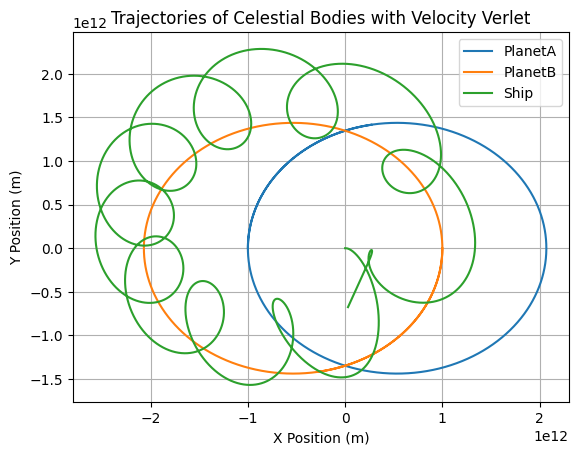

Ending Total Energy: -1.0871499986132795e+39


In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
# 可以向量化计算以提高效率，尤其是在处理大量天体时
# 定义天体类，包含质量、位置、速度、加速度等属性
class CelestialBody:
    def __init__(self, m, x0, y0, vx0, vy0, ax, ay, name=""):
        self.m = m
        self.x = x0
        self.y = y0
        self.vx = vx0
        self.vy = vy0
        self.ax = ax
        self.ay = ay
        self.name = name
        self.G = 6.67430e-11
    
class AdvancedGrabitySystem:
    def __init__(self, bodies):
        self.bodies = bodies
    
    def Compute_accel(self):
        for i in self.bodies:
            i.ax = 0  # 重置加速度
            i.ay = 0
            for j in self.bodies:
                if i != j:
                    dx = j.x - i.x
                    dy = j.y - i.y
                    r = math.sqrt(dx**2 + dy**2)
                    if r > 0:
                        F = i.G * i.m * j.m / r**2
                        ax = F * dx / r / i.m
                        ay = F * dy / r / i.m
                        i.ax += ax
                        i.ay += ay
    
    def step(self, dt):
        for body in self.bodies:
            body.x += body.vx * dt + 0.5 * body.ax * dt**2
            body.y += body.vy * dt + 0.5 * body.ay * dt**2
        
        old_ax = {body: body.ax for body in self.bodies}
        old_ay = {body: body.ay for body in self.bodies}
        
        self.Compute_accel()
        
        for body in self.bodies:
            body.vx += 0.5 * (old_ax[body] + body.ax) * dt
            body.vy += 0.5 * (old_ay[body] + body.ay) * dt

    def simulate(self, dt, total_steps):
        t = 0
        steps = 0
        data = []
        while steps <= total_steps:
            self.step(dt)
            t += dt
            steps += 1
            data.append((t, [(body.name, body.x, body.y) for body in self.bodies]))
        return data
    
    def plot_trajectories(self, dt, total_steps):
        data = self.simulate(dt, total_steps)
        for body in self.bodies:
            x_vals = [point[1][i][1] for point in data for i, b in enumerate(point[1]) if b[0] == body.name]
            y_vals = [point[1][i][2] for point in data for i, b in enumerate(point[1]) if b[0] == body.name]
            plt.plot(x_vals, y_vals, label=body.name)
        plt.xlabel('X Position (m)')
        plt.ylabel('Y Position (m)')
        plt.title('Trajectories of Celestial Bodies with Velocity Verlet')
        plt.legend()
        plt.grid()
        plt.show()
    
    def total_energy(self):
        kinetic = 0
        potential = 0
        for i in self.bodies:
            kinetic += 0.5 * i.m * (i.vx**2 + i.vy**2)
            for j in self.bodies:
                if i != j:
                    dx = j.x - i.x
                    dy = j.y - i.y
                    r = math.sqrt(dx**2 + dy**2)
                    if r > 0:
                        potential -= 0.5 * i.G * i.m * j.m / r
        return kinetic + potential
    

# 定义天体和系统，运行模拟并绘制轨迹
planetA=CelestialBody(10e30, -10e11, 0, 0, 15000, 0, 0, "PlanetA")
planetB=CelestialBody(10e30, 10e11, 0, 0, -15000, 0, 0, "PlanetB")
ship = CelestialBody(1000, 0, 0, 500, 0, 0, 0, "Ship")
total_bodies = [planetA, planetB, ship]
system = AdvancedGrabitySystem(total_bodies)

print("Starting Total Energy:", system.total_energy())
dt = float(input("Enter time step (s): "))
total_steps = int(input("Enter total steps: "))
system.plot_trajectories(dt, total_steps)

print("Ending Total Energy:", system.total_energy())



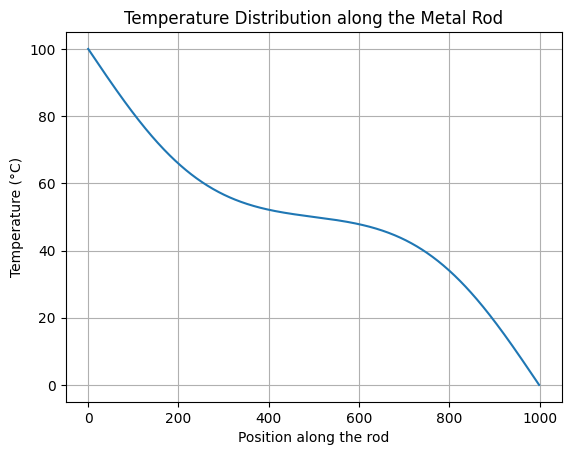